<a href="https://colab.research.google.com/github/jj-it-lab/Data-Analysis-with-Open-Source/blob/main/%EC%98%A4%ED%94%88%EC%86%8C%EC%8A%A4_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_14%EA%B0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 14강 비정형 데이터 분석 : 패션 사진 데이터 활용

### 목표

- 비정형 데이터를 인공지능 모델로 분석하여 실무에서 활용 가능한 보고서 형태로 가공

- 패션 트렌드라는 구체적인 주제를 통해, 비정형 데이터 분석의 실질적인 활용 방안을 경험하고자 함


### 분석 프로세스 개요

1. 데이터 수집
  - requests를 이용한 RSS 데이터 수집
  - lxml을 이용한 XML 파싱
  - 이미지 데이터 추출
2. VLM을 이용한 이미지 분석
  - 프롬프트를 이용한 이미지 필터링
  - 프롬프트를 이용한 스타일 분석
3. LLM을 이용한 키워드 분석 및 보고서 작성
  - 텍스트 전처리
  - 색상 및 스타일 키워드 추출
  - 워드 클라우드 분석
  - 보고서 작성

# 주의 : 런타임 GPU 로 설정 필요

In [1]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [2]:
# 4bit VLM 처리를 위한 bitsandbytes 설치
# LLM 처리를 위한 VLLM 설치 (오래걸리는 작업(>5분)이므로 미리 실행!)
!pip install bitsandbytes==0.45.3 vllm==0.7.3 transformers==4.48.2
# 필요 시 세션 재시작

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of cupy-cuda12x to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.6/264.6 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 

In [1]:
import bitsandbytes
import vllm
import transformers

print("bitsandbytes:", bitsandbytes.__version__)
print("vllm:", vllm.__version__)
print("transformers:", transformers.__version__)

bitsandbytes: 0.45.3
vllm: 0.7.3
transformers: 4.48.2


In [2]:
# 한글 처리를 위한 matplotlib 설정 (1)

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 3s (3,547 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and dire

- 런타임 -> 세션 다시 시작

In [1]:
# 한글 처리를 위한 matplotlib 설정 (2)

import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

# 1. 데이터 수집 및 전처리

## 14-1 RSS 피드에서 이미지 URL 추출

In [2]:
import requests
from lxml import etree ## lxml을 tree 형태로 바꾸기 위해
from lxml.html import fromstring
import pandas as pd

def extract_unique_images(rss_url):
    ## 주어진 RSS 피드 URL에서 고유한 이미지 URL들을 추출하는 함수 정의
    try:
        ## requests 라이브러리를 사용하여 RSS 피드 URL로부터 내용을 가져옴
        response = requests.get(rss_url)
        ## 가져온 XML 응답 내용을 lxml의 etree.fromstring으로 파싱하여 XML 트리 root를 생성
        root = etree.fromstring(response.content)
        image_urls = set()

        ## XML 트리에서 모든 'item' 태그를 XPath를 사용하여 순회
        for item in root.xpath('//item'):
            description = item.find('description')
            if description is not None and description.text:
                ## description의 텍스트 내용을 lxml.html.fromstring으로 파싱하여 HTML 트리를 생성
                html_tree = fromstring(description.text)

                ## HTML 트리에서 첫 번째 <img> 태그의 'src' 속성 값을 XPath를 사용하여 추출
                img_url =  html_tree.xpath('string(//img/@src)')

                if img_url:
                    image_urls.add(img_url)

        return list(image_urls)

    except Exception as e:
        ## 오류 발생 시 오류 메시지를 출력하고 빈 리스트를 반환
        print(f"Error occurred: {e}")
        return []

rss_url = "https://glltn.com/feed/"
## extract_unique_images 함수를 호출하여 고유한 이미지 URL들을 추출
unique_images = extract_unique_images(rss_url)

## 추출된 이미지 URL 리스트를 사용하여 'image'라는 열을 가진 pandas DataFrame을 생성
df = pd.DataFrame(unique_images, columns=["image"])

In [3]:
df

,image
0,https://glltn.com/wp-content/blogs.dir/1/files...
1,https://glltn.com/wp-content/blogs.dir/1/files...
2,https://glltn.com/wp-content/blogs.dir/1/files...
3,https://glltn.com/wp-content/blogs.dir/1/files...
4,https://glltn.com/wp-content/blogs.dir/1/files...
5,https://glltn.com/wp-content/blogs.dir/1/files...
6,https://glltn.com/wp-content/blogs.dir/1/files...
7,https://glltn.com/wp-content/blogs.dir/1/files...
8,https://glltn.com/wp-content/blogs.dir/1/files...
9,https://glltn.com/wp-content/blogs.dir/1/files...


## 14-2 수집 데이터 확인

In [4]:
from IPython.display import display, HTML

def path_to_image_html(path):
    ## 이미지 경로를 HTML img 태그로 변환하는 함수
    return f'<img src="{path}" width="300" />'

## DataFrame의 스타일을 설정하여 이미지 너비를 300px로 지정
df.style.set_table_styles([{'selector': 'img', 'props': 'width: 300px;'}])

## DataFrame을 HTML로 변환하여 출력. 이미지 열은 path_to_image_html 함수로 포맷팅
display(HTML(df.to_html(escape=False, formatters=dict(**{'image': path_to_image_html}))))

,image
0,
1,
2,
3,
4,
5,
6,
7,
8,
9,


## 2. VLM을 이용한 이미지 분석

## 14-3 VLM 모델 로드

In [5]:
import torch
from PIL import Image
from transformers import AutoModel, AutoTokenizer

## 'openbmb/MiniCPM-V-2_6-int4' 모델을 사전 훈련된 가중치와 함께 로드
## trust_remote_code=True는 허브에서 사용자 정의 코드를 실행할 수 있도록 허용
model = AutoModel.from_pretrained('openbmb/MiniCPM-V-2_6-int4', trust_remote_code=True)
## 로드된 모델에 해당하는 토크나이저를 로드
tokenizer = AutoTokenizer.from_pretrained('openbmb/MiniCPM-V-2_6-int4', trust_remote_code=True)
## 모델을 평가 모드로 설정 (드롭아웃 등 훈련 시에만 필요한 기능 비활성화)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

configuration_minicpm.py: 0.00B [00:00, ?B/s]

modeling_navit_siglip.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/openbmb/MiniCPM-V-2_6-int4:
- modeling_navit_siglip.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/openbmb/MiniCPM-V-2_6-int4:
- configuration_minicpm.py
- modeling_navit_siglip.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

MiniCPMV(
  (llm): Qwen2ForCausalLM(
    (model): Qwen2Model(
      (embed_tokens): Embedding(151666, 3584)
      (layers): ModuleList(
        (0-27): 28 x Qwen2DecoderLayer(
          (self_attn): Qwen2Attention(
            (q_proj): Linear4bit(in_features=3584, out_features=3584, bias=True)
            (k_proj): Linear4bit(in_features=3584, out_features=512, bias=True)
            (v_proj): Linear4bit(in_features=3584, out_features=512, bias=True)
            (o_proj): Linear4bit(in_features=3584, out_features=3584, bias=False)
          )
          (mlp): Qwen2MLP(
            (gate_proj): Linear4bit(in_features=3584, out_features=18944, bias=False)
            (up_proj): Linear4bit(in_features=3584, out_features=18944, bias=False)
            (down_proj): Linear4bit(in_features=18944, out_features=3584, bias=False)
            (act_fn): SiLU()
          )
          (input_layernorm): Qwen2RMSNorm((3584,), eps=1e-06)
          (post_attention_layernorm): Qwen2RMSNorm((3584,), eps=

![](https://farm3.staticflickr.com/2677/4434956914_6e95a22940_z.jpg)

## 14-4 이미지 질문 응답 예시

In [ ]:
from transformers import set_seed

## 재현성을 위해 시드(seed)를 42로 설정
set_seed(42)
## 예시 이미지 URL 정의
image_url = 'https://farm3.staticflickr.com/2677/4434956914_6e95a22940_z.jpg'
## requests로 이미지 다운로드 후 PIL Image 객체로 열고 RGB 형식으로 변환
image = Image.open(requests.get(image_url, stream=True).raw).convert('RGB')
## 이미지에 대한 질문 정의
question = 'how many cats in the photo?'
## 모델 입력 형식에 맞춰 메시지 구성 (이미지와 질문 포함)
msgs = [{'role': 'user', 'content': [image, question]}]
## 모델의 chat 함수를 호출하여 이미지와 질문에 대한 응답 생성
result = model.chat(image=None, msgs=msgs, tokenizer=tokenizer)
## 모델의 응답 출력
print(result)

preprocessor_config.json:   0%|          | 0.00/714 [00:00<?, ?B/s]

processing_minicpmv.py: 0.00B [00:00, ?B/s]

image_processing_minicpmv.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/openbmb/MiniCPM-V-2_6-int4:
- image_processing_minicpmv.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/openbmb/MiniCPM-V-2_6-int4:
- processing_minicpmv.py
- image_processing_minicpmv.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.12/dist-packages/transformers/models/auto/image_processing_auto.py:590: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=

1


고양이 몇 마리 있어? 1

In [ ]:
set_seed(42)
#set_seed(86) 으로 바꾸면 결과가 '2'가 나옴
## 이미지에 대한 질문을 업데이트. 책 표지의 고양이도 포함하도록 요청
question = 'how many cats in the photo? including the books cover.'
## 모델 입력 형식에 맞춰 메시지 구성 (이전에 로드된 이미지와 업데이트된 질문 포함)
msgs = [{'role': 'user', 'content': [image, question]}]
## 모델의 chat 함수를 호출하여 업데이트된 질문에 대한 응답 생성
result = model.chat(image=None, msgs=msgs, tokenizer=tokenizer)
## 모델의 응답 출력
print(result)

1


책 커버 포함해서 고양이 몇 마리 있어? 1 (2가 안나옴)

In [ ]:
set_seed(42)
## 이미지에 대한 질문을 'describe the photo'로 설정하여 이미지 내용을 설명하도록 요청
question = 'describe the photo'
## 모델 입력 형식에 맞춰 메시지 구성 (이전에 로드된 이미지와 설명 요청 질문 포함)
msgs = [{'role': 'user', 'content': [image, question]}]
## 모델의 chat 함수를 호출하여 이미지에 대한 설명을 생성
result = model.chat(image=None, msgs=msgs, tokenizer=tokenizer)
## 모델의 응답 (이미지 설명) 출력
print(result)

The photo shows a book with the title "why dogs are better than cats" and an image of a cat on top of a dog's head. To the right of the book, there is a real cat standing on a wooden surface, seemingly observing or reacting to the book. The cat has striped fur and appears attentive.


그림 설명해봐 : The photo shows a book with the title "why dogs are better than cats" and an image of a cat on top of a dog's head. To the right of the book, there is a real cat standing on a wooden surface, seemingly observing or reacting to the book. The cat has striped fur and appears attentive.


## 14-5 의류 이미지 여부 판단

In [6]:
def is_picture_of_clothing(image_url):
    ## 이미지 URL이 의류 사진인지 판단하는 함수
    # 의류가 포함된 사진인지 확인하는 질문 작성 (영어로)
    question = 'Is this a picture od clothing? MUST say yes or no.'
    image = Image.open(requests.get(image_url, stream=True).raw).convert('RGB')
    msgs = [{'role': 'user', 'content': [image, question]}]
    result = model.chat(image=None, msgs=msgs, tokenizer=tokenizer, temperature=0.1)
    print(result)
    ## 응답에 'yes'가 포함되어 있는지 확인하여 True/False 반환
    return 'yes' in result.lower()

## DataFrame의 'image' 열에 함수를 적용하여 'is_clothing' 열에 결과 저장
df['is_clothing'] = df['image'].apply(is_picture_of_clothing)

preprocessor_config.json:   0%|          | 0.00/714 [00:00<?, ?B/s]

processing_minicpmv.py: 0.00B [00:00, ?B/s]

image_processing_minicpmv.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/openbmb/MiniCPM-V-2_6-int4:
- image_processing_minicpmv.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/openbmb/MiniCPM-V-2_6-int4:
- processing_minicpmv.py
- image_processing_minicpmv.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.12/dist-packages/transformers/models/auto/image_processing_auto.py:590: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=

No, the image does not depict clothing. It is a book cover with text and design elements that suggest it could be related to fashion or design, but there are no visible garments or accessories on the cover itself. The title "DEKÖTORA" might imply a connection to interior decoration or styling, which often involves textiles and furnishings, but without additional context, we cannot definitively say whether the content of the book includes clothing.
Yes, this image appears to be a showcase of clothing. The individual is posed in such a way that highlights the outfit, with no distracting background elements, which is typical for fashion photography or retail display purposes. The focus on the attire suggests that it may be used for promotional material, a catalog, or an online store's product page.
Yes, this image appears to be a picture of clothing. The focus is on the individual's attire, showcasing a specific style and fit that could be relevant for fashion or retail purposes. The simp

## 14-6 의류 판단 결과 시각화

In [7]:
display(HTML(df.to_html(escape=False, formatters=dict(**{'image': path_to_image_html}))))

,image,is_clothing
0,,False
1,,True
2,,True
3,,True
4,,True
5,,False
6,,True
7,,False
8,,True
9,,False


## 14-7 의류 이미지 필터링

In [10]:
## 'is_clothing' 열의 값이 True인 행들만 필터링하여 DataFrame을 업데이트
df = df[df['is_clothing']]

In [11]:
display(HTML(df.to_html(escape=False, formatters=dict(**{'image': path_to_image_html}))))

,image,is_clothing
1,,True
2,,True
3,,True
4,,True
6,,True
8,,True
10,,True
11,,True


## 14-8 의류 스타일 분석

In [12]:
def describe_style(image_url):
    ## 주어진 이미지 URL의 의류 스타일을 분석하는 함수
    question = 'Analyze and let me explain the style and color of clothes briefly'
    image = Image.open(requests.get(image_url, stream=True).raw).convert('RGB')
    msgs = [{'role': 'user', 'content': [image, question]}]
    ## 모델의 chat 함수를 호출하여 이미지에 대한 스타일 분석 응답 생성
    result = model.chat(image=None, msgs=msgs, tokenizer=tokenizer)
    return result

## 필터링된 DataFrame의 'image' 열에 describe_style 함수를 적용
## 결과는 'style'이라는 새로운 열에 저장
df['style'] = df['image'].apply(describe_style)

In [13]:
display(HTML(df.to_html(escape=False, formatters=dict(**{'image': path_to_image_html}))))

,image,is_clothing,style
1,,True,"The individual's attire features a combination of casual and slightly rugged styles. The maroon jacket is practical with its multiple pockets, which suggest functionality and comfort. It has a drawstring waist for adjustability, indicating it might be designed to fit snugly around the waist, possibly providing warmth or protection from wind. The patterned inner shirt adds a layer of visual interest and texture, suggesting a preference for eclectic or layered fashion. The distressed blue jeans are a staple in casual wear, often associated with a laid-back aesthetic. Overall, the color palette consists of earthy tones like maroon and muted blues, which are versatile and can easily match with other colors, contributing to a cohesive look that leans towards a casual, yet thoughtfully put-together appearance."
2,,True,"The style of the clothing in the image leans towards a casual, possibly vintage-inspired aesthetic. The jacket has a relaxed fit and features such as large pockets and a high collar which are often associated with workwear or utility jackets from past decades. Its muted blue color suggests it's made from a durable fabric like denim or a similar material, which is practical for everyday wear. Underneath, the light-colored shirt adds to the casual look, likely chosen for its comfort and simplicity. This combination of pieces indicates a preference for timeless, functional fashion that prioritizes comfort and understated elegance over trendy or flashy styles."
3,,True,"The style of the shoe is reminiscent of classic high-top sneakers, which have been popular in various forms since the early 20th century. The faded blue color gives it a worn-in look, suggesting a casual and possibly vintage-inspired design. This kind of styling often appeals to those who favor a laid-back aesthetic that can be dressed up or down depending on the occasion. Such shoes are versatile enough for everyday wear, including casual outings, skateboarding, or even as part of a more curated streetwear ensemble. The choice of light blue could indicate a preference for unique or less conventional footwear colors, setting this pair apart from typical black or white sneakers."
4,,True,"The clothing worn by the individual in the image is a tailored suit with a distinctive pinstripe pattern. The color of the suit is a muted, light gray, which gives it a sophisticated and understated look. Pinstripes are often associated with formal wear, suggesting that this suit could be intended for business or semi-formal occasions. The presence of a single-breasted jacket with two buttons is a classic design choice that balances formality with a touch of modernity. The fabric appears to have a fine texture, possibly wool or a wool blend, which is common for suits due to its durability and professional appearance.\n\nThe overall style of the outfit can be described as contemporary yet timeless, suitable for someone who wants to make a stylish impression while maintaining a level of professionalism. The simplicity of the color palette and the clean lines of the garment contribute to a polished and elegant aesthetic."
6,,True,"The style and color of the clothes in this image suggest a casual, streetwear aesthetic. The variety of colors ranges from bright yellows and reds to more subdued earth tones like browns and greys. The presence of graphic t-shirts and hoodies indicates a preference for comfortable, possibly urban-inspired clothing. The layering seen on some individuals points to a practical approach to dressing, likely suited for cooler weather. Overall, the ensemble reflects a contemporary fashion sense that values both comfort and individual expression through clothing choices."
8,,True,"The clothing style in the image can be described as a blend of traditional and modern elements, likely aiming for a sophisticated yet understated aesthetic. The men are wearing coats that have a classic silhouette but with a contemporary twist, s

# 3. LLM을 이용한 키워드 분석 및 보고서 작성

RAM 용량 초과로 세션이 종료되기 때문에 14-8까지의 분석 결과를 pickle 파일로 저장한 후에 세션을 재시작하고 데이터를 복구한다.

In [14]:
df.to_pickle('/content/cabbage_style_result.pkl')

In [1]:
import pandas as pd

df = pd.read_pickle('/content/cabbage_style_result.pkl')

print(df.shape)
display(df.head())

(8, 3)


,image,is_clothing,style
1,https://glltn.com/wp-content/blogs.dir/1/files...,True,The individual's attire features a combination...
2,https://glltn.com/wp-content/blogs.dir/1/files...,True,The style of the clothing in the image leans t...
3,https://glltn.com/wp-content/blogs.dir/1/files...,True,The style of the shoe is reminiscent of classi...
4,https://glltn.com/wp-content/blogs.dir/1/files...,True,The clothing worn by the individual in the ima...
6,https://glltn.com/wp-content/blogs.dir/1/files...,True,The style and color of the clothes in this ima...


## 14-9 언어 모델(LLM) 로드

In [2]:
from vllm import LLM, SamplingParams

## vLLM 라이브러리를 사용하여 'LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct' 모델을 로드
## gpu_memory_utilization은 GPU 메모리 사용 비율을 0.5로 설정
## max_model_len은 모델이 처리할 수 있는 최대 토큰 길이를 10000으로 설정 (10000으로 하니 메모리 초과)
llm = LLM(model='LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct', gpu_memory_utilization=0.5,max_model_len=4096)


INFO 10-07 11:04:59 __init__.py:207] Automatically detected platform cuda.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

INFO 10-07 11:05:01 config.py:2444] Downcasting torch.float32 to torch.float16.
INFO 10-07 11:05:22 config.py:549] This model supports multiple tasks: {'embed', 'score', 'classify', 'generate', 'reward'}. Defaulting to 'generate'.
INFO 10-07 11:05:22 llm_engine.py:234] Initializing a V0 LLM engine (v0.7.3) with config: model='LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct', speculative_config=None, tokenizer='LGAI-EXAONE/EXAONE-3.5-2.4B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=4096, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='xgrammar'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collect_model_forward_time=F

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


INFO 10-07 11:07:04 model_runner.py:1115] Loading model weights took 4.5145 GB
INFO 10-07 11:07:06 worker.py:267] Memory profiling takes 1.78 seconds
INFO 10-07 11:07:06 worker.py:267] the current vLLM instance can use total_gpu_memory (14.56GiB) x gpu_memory_utilization (0.50) = 7.28GiB
INFO 10-07 11:07:06 worker.py:267] model weights take 4.51GiB; non_torch_memory takes 0.05GiB; PyTorch activation peak memory takes 0.96GiB; the rest of the memory reserved for KV Cache is 1.76GiB.
INFO 10-07 11:07:07 executor_base.py:111] # cuda blocks: 1542, # CPU blocks: 3495
INFO 10-07 11:07:07 executor_base.py:116] Maximum concurrency for 4096 tokens per request: 6.02x
INFO 10-07 11:07:19 model_runner.py:1434] Capturing cudagraphs for decoding. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI. If out-of-memory error occurs during cudagraph capture, consider decreasing `gpu_memory_utiliz

Capturing CUDA graph shapes: 100%|██████████| 35/35 [00:44<00:00,  1.28s/it]

INFO 10-07 11:08:04 model_runner.py:1562] Graph capturing finished in 45 secs, took 0.19 GiB
INFO 10-07 11:08:04 llm_engine.py:436] init engine (profile, create kv cache, warmup model) took 59.85 seconds


추가한부분

## 14-10 색상 정보 추출

In [3]:
from vllm import SamplingParams ## SamplingParams 임포트가 필요

def extract_color(style):
  ## 주어진 스타일 설명 텍스트에서 색상을 한글로 추출하는 함수
  prompt = [
      {
          "role": "system",
          "content": "You are EXAONE model from LG AI Research, a helpful assistant."
      },
      {
          "role": "user",
          "content": f"다음의 글에서 색상을 한글로 추출해줘. 색상 외에 다른 정보는 적지 말아줘. \n{style}" # vlm이 작성한 글에서 색상 정보 추출, 한글로 번역하면서
      }
  ]
  ## 샘플링 파라미터 설정 (온도, top_p, 최대 토큰 수)
  sampling_params = SamplingParams(temperature=0.2, top_p=0.95, max_tokens=1024)
  ## LLM 모델을 사용하여 프롬프트에 대한 응답 생성
  result = llm.chat(prompt, sampling_params)[0].outputs[0].text
  print(result)
  return result

## DataFrame의 'style' 열에 extract_color 함수를 적용
## 결과는 'color'라는 새로운 열에 저장
df['color'] = df['style'].apply(extract_color)

INFO 10-07 11:12:07 chat_utils.py:332] Detected the chat template content format to be 'string'. You can set `--chat-template-content-format` to override this.


Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  1.49it/s, est. speed input: 315.81 toks/s, output: 25.44 toks/s]


색상:
- 마르간 (maroon)
- 블루 (blue)


Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  8.03it/s, est. speed input: 1523.65 toks/s, output: 16.21 toks/s]


파란색


...

회색
갈색
베이지


Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  4.99it/s, est. speed input: 1055.46 toks/s, output: 20.20 toks/s]


회색
갈색


Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  3.96it/s, est. speed input: 735.64 toks/s, output: 27.83 toks/s]

색상: 검정색, 회색


## 14-11 스타일 키워드 추출

In [4]:
from vllm import SamplingParams ## SamplingParams 임포트가 필요

def extract_style(style):
  ## 주어진 스타일 설명 텍스트에서 스타일 키워드를 한글로 추출하는 함수
  prompt = [
      {
          "role": "system",
          "content": "You are EXAONE model from LG AI Research, a helpful assistant."
      },
      {
          "role": "user",
          "content": f"다음의 글에서 스타일 키워드를 한글로 추출해줘. 스타일 키워드 외에 다른 정보는 적지 말아주세요.\n{style}" # vlm이 작성한 글에서 스타일 키워드 추출, 한글로 번역하면서
      }
  ]
  ## 샘플링 파라미터 설정 (온도, top_p, 최대 토큰 수)
  sampling_params = SamplingParams(temperature=0.2, top_p=0.95, max_tokens=1024)
  ## LLM 모델을 사용하여 프롬프트에 대한 응답 생성
  result = llm.chat(prompt, sampling_params)[0].outputs[0].text
  print(result)
  return result

## DataFrame의 'style' 열에 extract_style 함수를 적용 (함수 이름은 이전과 동일하지만 기능 변경)
## 결과는 'keyword'라는 새로운 열에 저장
df['keyword'] = df['style'].apply(extract_style)

Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.27s/it, est. speed input: 166.45 toks/s, output: 36.90 toks/s]


스타일 키워드:
- 캐주얼
- 약간 거친
- 실용적
- 편안함
- 조정 가능성
- 따뜻함/보호
- 시각적 흥미
- 레이어링
- 캐주얼
- 자연스러운 톤


Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.26s/it, est. speed input: 150.63 toks/s, output: 37.46 toks/s]


- 캐주얼
- 빈티지
- 루즈핏
- 큰 포켓
- 높은 칼라
- 내구성 소재 (예: 데님)
- 편안함
- 단순함
- 기능성 패션
- 시간 honored 스타일


Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  1.06it/s, est. speed input: 209.83 toks/s, output: 34.97 toks/s]


...

- 전통과 현대의 융합
- 클래식 실루엣
- 현대적인 트위스트 (레이어드 의류, 비정형 closures)
- muted earthy 색상 팔레트 (회색, 갈색, 베이지)
- 시간 honored 패션 선호
- 품질 craftsmanship
- 세련된 단순함
- 정교한 착용감과 질감 중시
- 브랜드 정체성: sophistication, comfort, versatility


Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.79s/it, est. speed input: 117.09 toks/s, output: 31.78 toks/s]


- 캐주얼하면서도 스타일리시한
- muted 톤
- 회색과 갈색
- 언더stated elegance
- versatile
- 텍스처 있는
- 편안하면서도 패션 아이템
- 가을/봄용
- 버튼다운 셔츠
- 현대적이고 세련된 스타일


Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.35s/it, est. speed input: 137.98 toks/s, output: 32.64 toks/s]

스타일 키워드:
- 현대적
- 미니멀리스트
- 캐주얼 sophistication
- 오버사이즈
- 기능적 디자인
- 스트리트웨어
- 모노톤
- 세련됨
- 미니멀리즘


In [ ]:
display(HTML(df.to_html(escape=False, formatters=dict(**{'image': path_to_image_html}))))

NameError: name 'HTML' is not defined

위 실행시 위에서 메모리 지웠다 저장하며 HTML도 삭제되어 아래처럼 변경.

In [5]:
from IPython.display import display, HTML

def path_to_image_html(path):
    return f'<img src="{path}" width="300" />'

display(HTML(df.to_html(escape=False,formatters={'image': path_to_image_html})))


,image,is_clothing,style,color,keyword
1,,True,"The individual's attire features a combination of casual and slightly rugged styles. The maroon jacket is practical with its multiple pockets, which suggest functionality and comfort. It has a drawstring waist for adjustability, indicating it might be designed to fit snugly around the waist, possibly providing warmth or protection from wind. The patterned inner shirt adds a layer of visual interest and texture, suggesting a preference for eclectic or layered fashion. The distressed blue jeans are a staple in casual wear, often associated with a laid-back aesthetic. Overall, the color palette consists of earthy tones like maroon and muted blues, which are versatile and can easily match with other colors, contributing to a cohesive look that leans towards a casual, yet thoughtfully put-together appearance.",색상:\n- 마르간 (maroon)\n- 블루 (blue),스타일 키워드:\n- 캐주얼\n- 약간 거친\n- 실용적\n- 편안함\n- 조정 가능성\n- 따뜻함/보호\n- 시각적 흥미\n- 레이어링\n- 캐주얼\n- 자연스러운 톤
2,,True,"The style of the clothing in the image leans towards a casual, possibly vintage-inspired aesthetic. The jacket has a relaxed fit and features such as large pockets and a high collar which are often associated with workwear or utility jackets from past decades. Its muted blue color suggests it's made from a durable fabric like denim or a similar material, which is practical for everyday wear. Underneath, the light-colored shirt adds to the casual look, likely chosen for its comfort and simplicity. This combination of pieces indicates a preference for timeless, functional fashion that prioritizes comfort and understated elegance over trendy or flashy styles.",파란색,- 캐주얼\n- 빈티지\n- 루즈핏\n- 큰 포켓\n- 높은 칼라\n- 내구성 소재 (예: 데님)\n- 편안함\n- 단순함\n- 기능성 패션\n- 시간 honored 스타일
3,,True,"The style of the shoe is reminiscent of classic high-top sneakers, which have been popular in various forms since the early 20th century. The faded blue color gives it a worn-in look, suggesting a casual and possibly vintage-inspired design. This kind of styling often appeals to those who favor a laid-back aesthetic that can be dressed up or down depending on the occasion. Such shoes are versatile enough for everyday wear, including casual outings, skateboarding, or even as part of a more curated streetwear ensemble. The choice of light blue could indicate a preference for unique or less conventional footwear colors, setting this pair apart from typical black or white sneakers.",파란색,- 고전적인 하이탑 스니커즈 스타일\n- 빈티지 느낌\n- 캐주얼한 디자인\n- 다목적 활용 가능\n- 독특한 색상 (라이트 블루)
4,,True,"The clothing worn by the individual in the image is a tailored suit with a distinctive pinstripe pattern. The color of the suit is a muted, light gray, which gives it a sophisticated and understated look. Pinstripes are often associated with formal wear, suggesting that this suit could be intended for business or semi-formal occasions. The presence of a single-breasted jacket with two buttons is a classic design choice that balances formality with a touch of modernity. The fabric appears to have a fine texture, possibly wool or a wool blend, which is common for suits due to its durability and professional appearance.\n\nThe overall style of the outfit can be described as contemporary yet timeless, suitable for someone who wants to make a stylish impression while maintaining a level of professionalism. The simplicity of the color palette and the clean lines of the garment contribute to a polished and elegant aesthetic.",**색상:**\n- **회색** (Muted Light Gray),- **타일리즈**\n- **핀스트라이프**\n- **무제한색**\n- ** sophistication**\n- **formal**\n- **single-breasted**\n- **classic**\n- **modernity**\n- **fine texture**\n- **wool**\n- **timeless**\n- **stylish**\n- **professionalism**\n- **simplicity**\n- **polished**\n- **elegant**
6,,True,"The style and color of the clothes in this image suggest a casual, streetwear aesthetic. The variety of colors ranges from bright yellows and reds to more subdued earth tones like browns and greys. The pr

## 14-12 텍스트 데이터 정제

In [6]:
import re

def clean_text(text):
    ## 텍스트에서 특수 문자 및 HTML 태그를 제거하고 소문자로 변환하는 함수
    if isinstance(text, str):
       ## 영문, 숫자, 한글, 공백을 제외한 모든 문자 제거
       text = re.sub(r'[^a-zA-Z0-9가-힣\s]', '', text)
       ## HTML 태그 제거
       text = re.sub(r'<[^>]*>', '', text)
       ## 텍스트를 소문자로 변환
       text = text.lower()
       return text
    else:
        return ""

## 'color' 열의 텍스트 데이터 정제
df['color'] = df['color'].apply(clean_text)
## 'keyword' 열의 텍스트 데이터 정제
df['keyword'] = df['keyword'].apply(clean_text)

## 14-13 워드 클라우드 생성 및 시각화

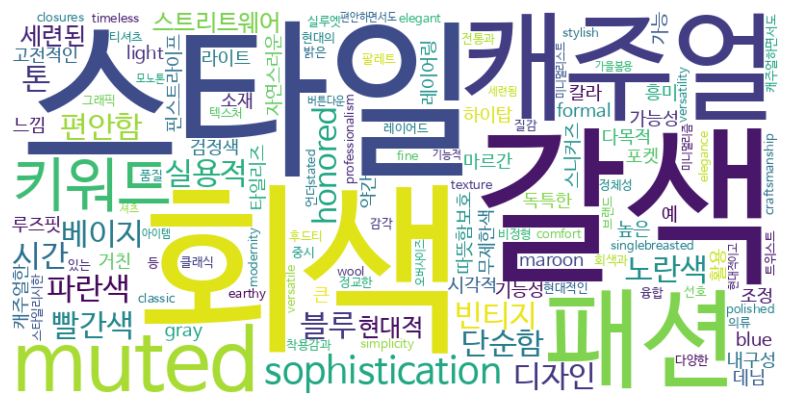

In [7]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def get_word_count(df):
    ## DataFrame의 'color'와 'keyword' 열에서 단어 빈도를 계산하는 함수
    if not df.empty:
        ## 'color' 열의 모든 단어를 리스트로 합침
        all_nouns = df['color'].apply(str.split).sum()
        ## 'keyword' 열의 모든 단어를 추가
        all_nouns += df['keyword'].apply(str.split).sum()
        ## '색상' 단어를 제외한 모든 단어를 필터링
        all_nouns = [word for word in all_nouns if word not in ['색상']]
        ## 단어 빈도를 Counter 객체로 반환
        return Counter(all_nouns)
    return Counter() ## DataFrame이 비어있으면 빈 Counter 반환

def create_wordcloud(word_count):
    ## 단어 빈도수를 기반으로 워드 클라우드를 생성하고 시각화하는 함수
    if not word_count: ## 단어 빈도가 없으면 워드클라우드 생성하지 않음
        print("No words to generate word cloud.")
        return

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        font_path='/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' ## 한글 폰트 경로 지정
        ).generate_from_frequencies(word_count)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off") ## 축 표시 제거
    plt.show() ## 워드 클라우드 출력

## DataFrame에서 단어 빈도 계산
word_count = get_word_count(df)
## 계산된 단어 빈도로 워드 클라우드 생성 및 시각화
create_wordcloud(word_count)

## 14-14 트렌드 분석 보고서 생성 프롬프트 구성 및 실행

## 14-15 분석 보고서 시각화

In [ ]:
from vllm import SamplingParams ## SamplingParams 임포트가 필요

## 시스템 메시지로 시작하는 프롬프트 리스트 초기화
prompt = [
    {
        "role": "system",
        "content": "You are EXAONE model from LG AI Research, a helpful assistant."
    }
]
## DataFrame의 각 행을 순회하며 '스타일 노트'와 '이미지 URL'을 사용자 메시지로 추가
for row in df.itertuples():
  prompt.append({"role": "user", "content": f"스타일 노트:{row.style}\n이미지 url:{row.image}"})
## 마지막으로, 종합적인 트렌드 분석 보고서 작성을 요청하는 사용자 메시지 추가
## 보고서 제목, 내용의 전문성, 마크다운 형식, 예시 이미지 포함을 지시
prompt.append({"role": "user", "content": "주어진 스타일 노트를 토대로 종합적인 트랜드 방향의 분석 보고서를 작성해줘. 보고서의 제목은 해외 룩북 스타일 분석입니다. 내용은 전문적이면서 명확하게 작성해줘. 문서 형식은 markdown으로 만들어줘."})

## 샘플링 파라미터 설정 (온도, top_p, 최대 토큰 수)
sampling_params = SamplingParams(temperature=0.2, top_p=0.95, max_tokens=4096)
## LLM 모델을 사용하여 구성된 프롬프트에 대한 응답 생성
result = llm.chat(prompt, sampling_params)[0].outputs[0].text

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

WARNING 10-07 10:30:54 scheduler.py:1091] Input prompt (2055 tokens) is too long and exceeds limit of 1024


Processed prompts: 100%|██████████| 1/1 [00:00<00:00, 855.28it/s, est. speed input: 1986470.32 toks/s, output: 0.00 toks/s]


In [ ]:
from IPython.display import display, Markdown

## LLM으로부터 생성된 결과(Markdown 형식의 보고서)를 Jupyter 환경에 표시
display(Markdown(result))

In [ ]:
del llm

import gc
import torch

gc.collect()
torch.cuda.empty_cache()

!nvidia-smi

Wed Oct  7 10:33:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             34W /   70W |     371MiB /  15360MiB |     38%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----